<a href="https://colab.research.google.com/github/Moushmika/Two_wheeler-resale_prediction/blob/main/MLE_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving BIKE DETAILS.csv to BIKE DETAILS.csv


In [ ]:
df = pd.read_csv('BIKE DETAILS.csv')

df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [ ]:
df.shape

(1061, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


In [ ]:
df.isnull().sum()

,0
name,0
selling_price,0
year,0
seller_type,0
owner,0
km_driven,0
ex_showroom_price,435


In [ ]:
current_year = 2025

df['bike_age'] = current_year - df['year']

df[['year','bike_age']].head()

,year,bike_age
0,2019,6
1,2017,8
2,2018,7
3,2015,10
4,2011,14


In [ ]:
df['ex_showroom_price'].median()

72752.5

In [ ]:
df['ex_showroom_price'].fillna(
    df['ex_showroom_price'].median(),
    inplace=True
)

/tmp/ipykernel_1595/2690465952.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ex_showroom_price'].fillna(


In [ ]:
df.isnull().sum()

,0
name,0
selling_price,0
year,0
seller_type,0
owner,0
km_driven,0
ex_showroom_price,0
bike_age,0


In [ ]:
df['selling_price'].describe()

,selling_price
count,1061.000000
mean,59638.151744
std,56304.291973
min,5000.000000
25%,28000.000000
50%,45000.000000
75%,70000.000000
max,760000.000000


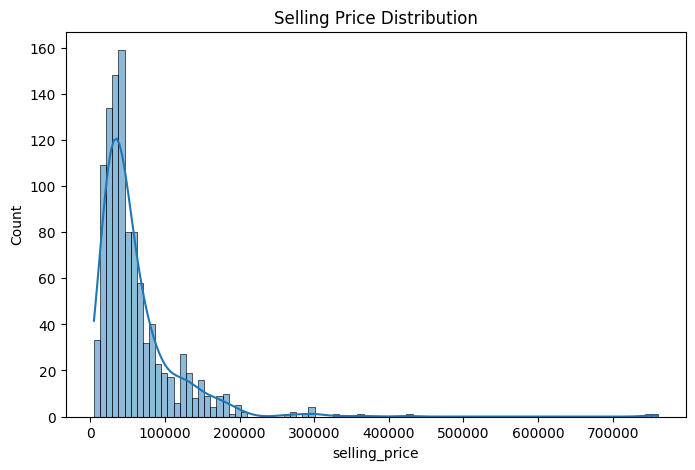

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df['selling_price'], kde=True)

plt.title("Selling Price Distribution")

plt.show()

In [ ]:
numeric_cols = [
    'selling_price',
    'bike_age',
    'km_driven',
    'ex_showroom_price'
]

corr = df[numeric_cols].corr()4

corr

,selling_price,bike_age,km_driven,ex_showroom_price
selling_price,1.000000,-0.402188,-0.212937,0.744075
bike_age,-0.402188,1.000000,0.288675,-0.100066
km_driven,-0.212937,0.288675,1.000000,-0.086791
ex_showroom_price,0.744075,-0.100066,-0.086791,1.000000


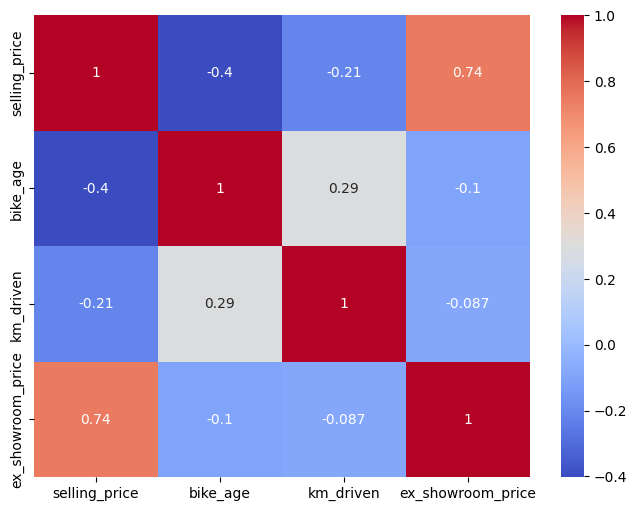

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,

    annot=True,
    cmap='coolwarm'
)

plt.show()

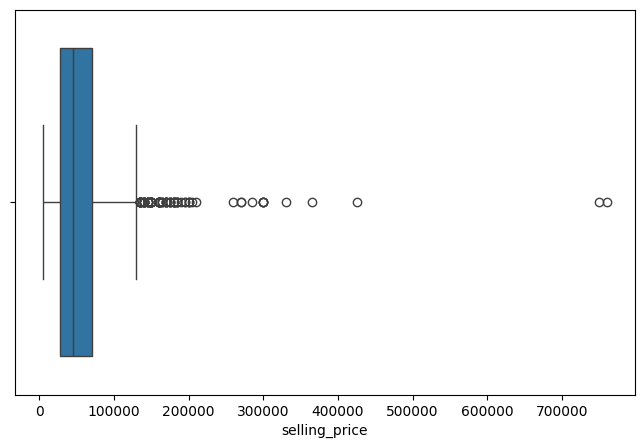

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['selling_price']
)

plt.show()

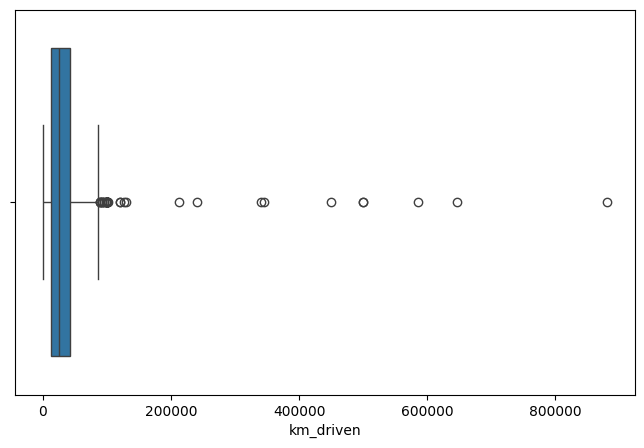

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['km_driven']
)

plt.show()

In [ ]:
df['brand'] = df['name'].str.split().str[0]

df[['name','brand']].head()

,name,brand
0,Royal Enfield Classic 350,Royal
1,Honda Dio,Honda
2,Royal Enfield Classic Gunmetal Grey,Royal
3,Yamaha Fazer FI V 2.0 [2016-2018],Yamaha
4,Yamaha SZ [2013-2014],Yamaha


In [ ]:
brand_price = df.groupby(
    'brand'
)['selling_price'].mean()

brand_price.sort_values(
    ascending=False
).head(10)

,selling_price
brand,
Harley-Davidson,540000.000000
BMW,300000.000000
Kawasaki,287500.000000
Jawa,175000.000000
Benelli,160000.000000
UM,156666.666667
KTM,155708.333333
Hyosung,135000.000000
Royal,128549.541284


In [ ]:
df['selling_price'].describe()

,selling_price
count,1061.000000
mean,59638.151744
std,56304.291973
min,5000.000000
25%,28000.000000
50%,45000.000000
75%,70000.000000
max,760000.000000


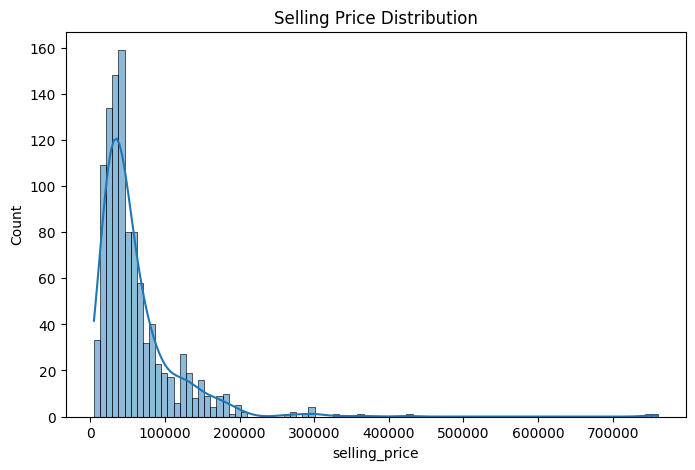

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    df['selling_price'],
    kde=True
)

plt.title("Selling Price Distribution")

plt.show()

In [ ]:
X = df[
    [
        'bike_age',
        'km_driven',
        'seller_type',
        'owner',
        'brand',
        'ex_showroom_price'
    ]
]

y = df['selling_price']

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'seller_type',
    'owner',
    'brand'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(848, 6)
(213, 6)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['seller_type', 'owner',
                                                   'brand'])])),
                ('regressor', LinearRegression())])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

print("R2 Score =", r2)

print("MAE =", mae)

print("RMSE =", rmse)

R2 Score = 0.807231355208722
MAE = 16192.325648338501
RMSE = 22545.29717150376


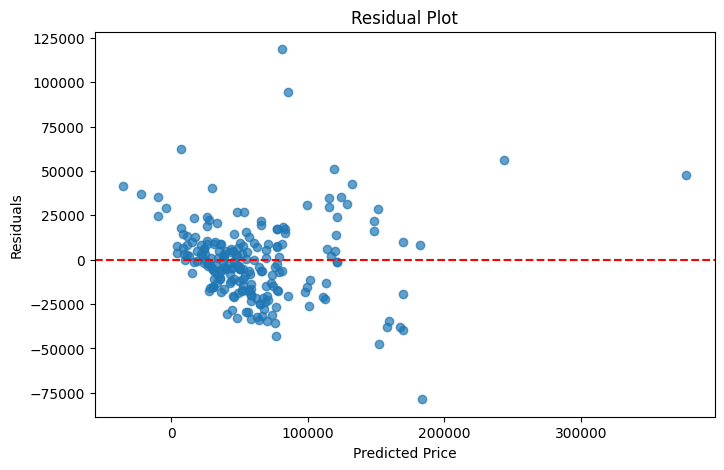

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

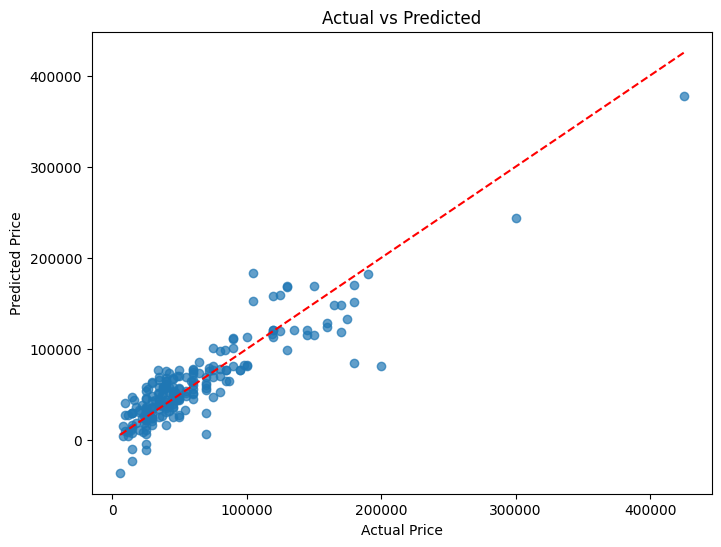

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [ ]:
feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = model.named_steps[
    'regressor'
].coef_

import pandas as pd

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance.sort_values(
    by='Coefficient',
    ascending=False
).head(20)

,Feature,Coefficient
18,cat__brand_Royal,45600.636768
15,cat__brand_KTM,16242.608672
2,cat__owner_1st owner,3681.604064
4,cat__owner_3rd owner,2391.831625
14,cat__brand_Jawa,2051.768611
19,cat__brand_Suzuki,597.190390
9,cat__brand_Benelli,295.822867
5,cat__owner_4th owner,281.054738
1,cat__seller_type_Individual,244.287629
21,cat__brand_UM,219.176588


In [ ]:
from scipy.stats import ttest_ind

royal = df[
    df['brand'] == 'Royal'
]['selling_price']

bajaj = df[
    df['brand'] == 'Bajaj'
]['selling_price']

t_stat, p_val = ttest_ind(
    royal,
    bajaj
)

print("T Statistic:", t_stat)
print("P Value:", p_val)

T Statistic: 21.96338956886553
P Value: 7.350068840707986e-69


In [ ]:
if p_val < 0.05:
    print("Reject H0")
    print("Significant Difference")
else:
    print("Fail to Reject H0")

Reject H0
Significant Difference


In [ ]:
feature_names = model.named_steps[
    'preprocessor'
].get_feature_names_out()

coefficients = model.named_steps[
    'regressor'
].coef_

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance.sort_values(
    by='Coefficient',
    ascending=False
).head(20)

,Feature,Coefficient
18,cat__brand_Royal,45600.636768
15,cat__brand_KTM,16242.608672
2,cat__owner_1st owner,3681.604064
4,cat__owner_3rd owner,2391.831625
14,cat__brand_Jawa,2051.768611
19,cat__brand_Suzuki,597.190390
9,cat__brand_Benelli,295.822867
5,cat__owner_4th owner,281.054738
1,cat__seller_type_Individual,244.287629
21,cat__brand_UM,219.176588


In [ ]:
feature_names = (
    model.named_steps['preprocessor']
    .get_feature_names_out()
)

print(feature_names)

['cat__seller_type_Dealer' 'cat__seller_type_Individual'
 'cat__owner_1st owner' 'cat__owner_2nd owner' 'cat__owner_3rd owner'
 'cat__owner_4th owner' 'cat__brand_Activa' 'cat__brand_Aprilia'
 'cat__brand_Bajaj' 'cat__brand_Benelli' 'cat__brand_Harley-Davidson'
 'cat__brand_Hero' 'cat__brand_Honda' 'cat__brand_Hyosung'
 'cat__brand_Jawa' 'cat__brand_KTM' 'cat__brand_Kawasaki'
 'cat__brand_Mahindra' 'cat__brand_Royal' 'cat__brand_Suzuki'
 'cat__brand_TVS' 'cat__brand_UM' 'cat__brand_Vespa' 'cat__brand_Yamaha'
 'cat__brand_Yo' 'remainder__bike_age' 'remainder__km_driven'
 'remainder__ex_showroom_price']
